In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets # for importing different datasets directly
import sklearn.model_selection
import sklearn.linear_model
from sklearn.model_selection import train_test_split # for splitting our data into training and testing set
from xgboost import XGBRegressor # Extreme gradient boosting algoirthm for regression
from sklearn import metrics # model evaluation

In [72]:
housing_price_dataset = sklearn.datasets.fetch_california_housing()

In [73]:
print(housing_price_dataset) # target values represent housing prices

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [74]:
# Loading the dataset to a pandas dataframe
house_price_dataframe = pd.DataFrame(housing_price_dataset.data, columns = housing_price_dataset.feature_names) # Columns represent name of all the features

In [75]:
# Adding the Target column (Prices of houses) to data frame
house_price_dataframe['Price'] = housing_price_dataset.target

In [76]:
# Printing first 5 rows of dataframe with Price of houses included
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [77]:
# Checking number of rows and columns in the dataframe
house_price_dataframe.shape

(20640, 9)

In [78]:
# Checking missing values
house_price_dataframe.isnull().sum()
# if there were null values (in this case there arent any) then we would've used methods like dropping or imputation

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [79]:
# statistical measures of data (mean , standard deviation , min value , max value)
house_price_dataframe.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


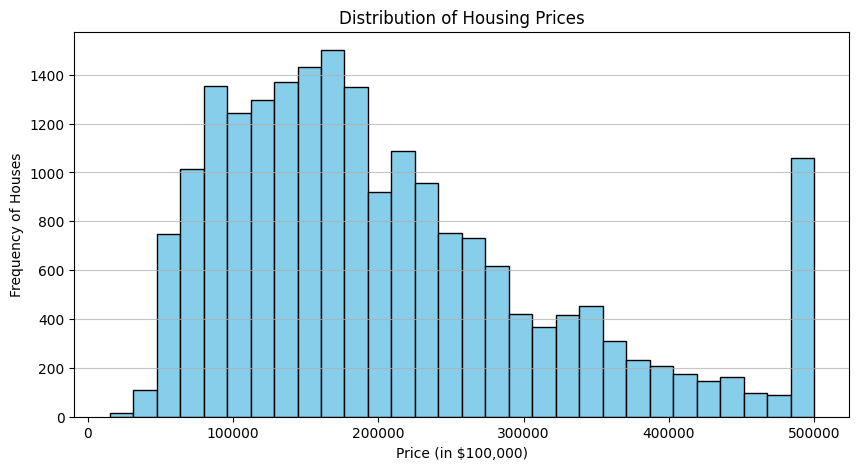

In [80]:
# Histogram of Housing Prices
plt.figure(figsize=(10, 5))
plt.hist(house_price_dataframe['Price'] * 100000, bins=30, color='skyblue', edgecolor='black')  # Converting price to hundreds of thousands
plt.title('Distribution of Housing Prices')
plt.xlabel('Price (in $100,000)')
plt.ylabel('Frequency of Houses')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [81]:
# Checking Correlation between features (How they are related to each other)
# Consists of Positive correlation (if one value increases the other also increases) and negative correlation (if one value increases the other value decreases)

correlation = house_price_dataframe.corr()

<Axes: >

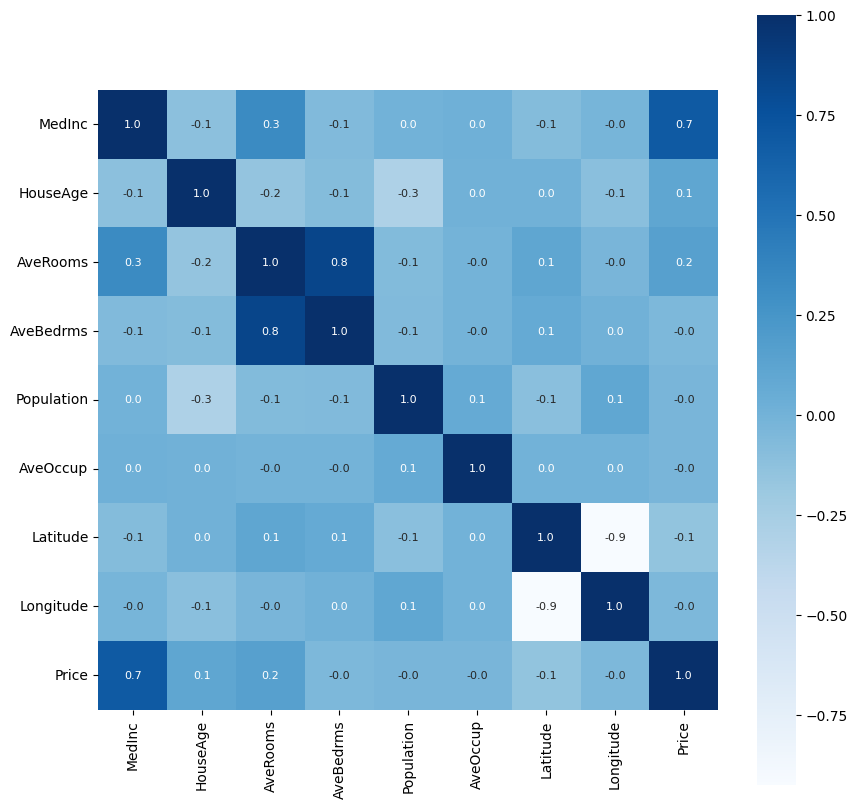

In [82]:
# Constructing a heatmap to undersatnd correlation
plt.figure(figsize = (10,10))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size':8}, cmap = 'Blues')
# Cbar - color map at the side will be displayed
# valyes to be displayed in a sqaure
# fmt tells how many floating values we want eg 0.1 fir '.1f'
# Annot tells all the feature names and annot_kws sets the size of the annotations
# cmap color of heat map (darker color = +ve correlation , lighter color = -ve correlation)

In [83]:
#Splitting the data and Target (Price)
X = house_price_dataframe.drop(['Price'], axis = 1)
Y = house_price_dataframe['Price']

In [84]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [85]:
# Step 1: Split into train+val and test sets (80% for train+val, 20% for test)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [86]:
# Step 2: Split train+val set into training and validation sets (75% of train+val for training, 25% for validation)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.25, random_state=2)

In [87]:
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (12384, 8)
Validation set shape: (4128, 8)
Test set shape: (4128, 8)


In [88]:
# Training the model
model = XGBRegressor(n_estimators=1000, learning_rate=0.05) # Decision tree based (Using more than 1 model)

In [89]:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [90]:
# Evaluating our model
# Accuracy on training data
training_data_prediction = model.predict(X_train) # Checking how well the model is performing by predicting values from trainning set

In [91]:
print(training_data_prediction)

[2.6694293 1.5784634 0.8169019 ... 1.7144148 4.019334  3.0160246]


In [92]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction) # Y train is orignal values and training_data_prediction is what our model has calculated

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error : ", score_1) # lesser the value more accurate the model is (Cost function)
print("Mean absolute error : ", score_2)

R squared error :  0.9753846218462535
Mean absolute error :  0.12861494473290805


In [93]:
# Checking model's performance on Validation set
validation_data_prediction = model.predict(X_val)

In [94]:
print(validation_data_prediction)

[0.524385  2.227979  1.9090672 ... 1.9978126 1.8106899 1.4276855]


In [95]:
# R squared error
score_1 = metrics.r2_score(Y_val, validation_data_prediction) # Y train is orignal values and training_data_prediction is what our model has calculated

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_val, validation_data_prediction)

print("R squared error : ", score_1) # lesser the value more accurate the model is (Cost function)
print("Mean absolute error : ", score_2)

R squared error :  0.8468127271472671
Mean absolute error :  0.2922562515793394


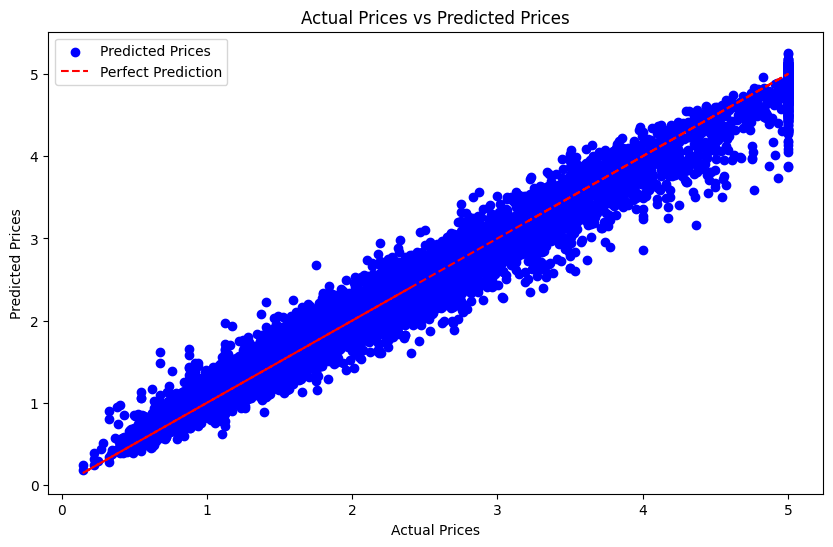

In [96]:
# Visualize actual and predicted prices with a line of equality
plt.figure(figsize=(10, 6))
plt.scatter(Y_train, training_data_prediction, color='blue', label='Predicted Prices')
plt.plot(Y_train, Y_train, color='red', linestyle='--', label='Perfect Prediction')  # Line of equality
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

In [97]:
# Checking our model's performance on testing data
testing_data_prediction = model.predict(X_test)

In [98]:
print(testing_data_prediction)

[2.8923032  1.8844632  0.79456437 ... 1.7137718  0.92097396 1.9911492 ]


In [99]:
# R squared error
score_1 = metrics.r2_score(Y_test, testing_data_prediction) # Y train is orignal values and training_data_prediction is what our model has calculated

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_test, testing_data_prediction)

print("R squared error : ", score_1) # lesser the value more accurate the model is (Cost function)
print("Mean absolute error : ", score_2)

R squared error :  0.8395011440914142
Mean absolute error :  0.30160593717350054


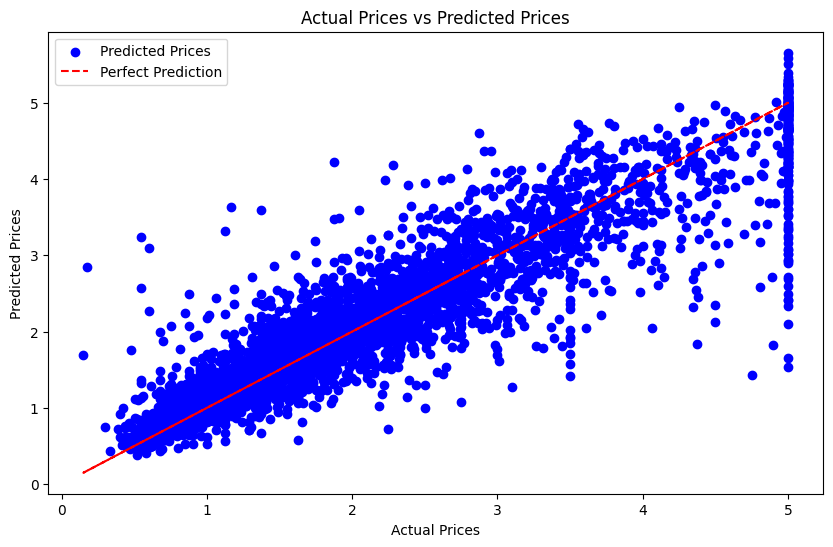

In [101]:
# Visualize actual and predicted prices with a line of equality
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, testing_data_prediction, color='blue', label='Predicted Prices')
plt.plot(Y_test, Y_test, color='red', linestyle='--', label='Perfect Prediction')  # Line of equality
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()